In [8]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Garbage collector for memory management
import gc

# System specific parameters and memory profiling
import os
import psutil

# Function to monitor current RAM usage
def print_memory_usage():
    process = psutil.Process(os.getpid())
    memory_megabytes = process.memory_info().rss / (1024 * 1024)
    print(f"Current RAM usage: {memory_megabytes:.2f} MB")

# Initial memory check before loading any data
print_memory_usage()

Current RAM usage: 37.64 MB


In [9]:
import pandas as pd
import numpy as np
import psutil
import os

# Function to monitor current RAM usage
def print_memory_usage():
    process = psutil.Process(os.getpid())
    memory_megabytes = process.memory_info().rss / (1024 * 1024)
    print(f"Current RAM usage: {memory_megabytes:.2f} MB")

# Function to downcast data types to the smallest possible format
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            # Convert strings to category type to save RAM
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%\n'.format(100 * (start_mem - end_mem) / start_mem))
    
    return df

# Define data path
data_path = './data/ashrae-energy-prediction/'

# 1. Load and compress building metadata
print("--- Loading and compressing building_metadata.csv ---")
building_df = pd.read_csv(data_path + 'building_metadata.csv')
building_df = reduce_mem_usage(building_df)

# 2. Load and compress weather data
print("--- Loading and compressing weather_train.csv ---")
weather_df = pd.read_csv(data_path + 'weather_train.csv')
weather_df = reduce_mem_usage(weather_df)

# 3. Load and compress the 20M rows dataset
print("--- Loading and compressing train.csv ---")
train_df = pd.read_csv(data_path + 'train.csv')
train_df = reduce_mem_usage(train_df)

# Final memory check after loading
print("--- Final Memory Check ---")
print_memory_usage()

--- Loading and compressing building_metadata.csv ---
Memory usage of dataframe is 0.07 MB
Memory usage after optimization is: 0.02 MB
Decreased by 73.9%

--- Loading and compressing weather_train.csv ---
Memory usage of dataframe is 9.60 MB
Memory usage after optimization is: 2.59 MB
Decreased by 73.1%

--- Loading and compressing train.csv ---
Memory usage of dataframe is 616.95 MB
Memory usage after optimization is: 173.84 MB
Decreased by 71.8%

--- Final Memory Check ---
Current RAM usage: 2238.83 MB


In [10]:
import gc

print("--- 1. Merging Train and Building Metadata ---")
# Left join train_df and building_df on 'building_id'
train_df = train_df.merge(building_df, on='building_id', how='left')

# Memory management: Delete building_df and force garbage collection
del building_df
gc.collect()
print("Merge 1 complete. building_metadata removed from RAM.")

print("--- 2. Merging with Weather Data ---")
# Left join train_df and weather_df on 'site_id' and 'timestamp'
train_df = train_df.merge(weather_df, on=['site_id', 'timestamp'], how='left')

# Memory management: Delete weather_df and force garbage collection
del weather_df
gc.collect()
print("Merge 2 complete. weather_train removed from RAM.")

print("--- 3. Final Memory Check After Merging ---")
# Display dataset structure and current RAM usage
train_df.info()
print_memory_usage()

--- 1. Merging Train and Building Metadata ---
Merge 1 complete. building_metadata removed from RAM.
--- 2. Merging with Weather Data ---
Merge 2 complete. weather_train removed from RAM.
--- 3. Final Memory Check After Merging ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20216100 entries, 0 to 20216099
Data columns (total 16 columns):
 #   Column              Dtype   
---  ------              -----   
 0   building_id         int16   
 1   meter               int8    
 2   timestamp           category
 3   meter_reading       float32 
 4   site_id             int8    
 5   primary_use         category
 6   square_feet         int32   
 7   year_built          float16 
 8   floor_count         float16 
 9   air_temperature     float16 
 10  cloud_coverage      float16 
 11  dew_temperature     float16 
 12  precip_depth_1_hr   float16 
 13  sea_level_pressure  float16 
 14  wind_direction      float16 
 15  wind_speed          float16 
dtypes: category(2), float16(9), float32(

In [11]:
import gc

print("--- 1. Converting Timestamp and Sorting ---")
# Convert timestamp back to datetime format for time-series operations
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])

# Sort values chronologically by site_id to prepare for accurate interpolation
train_df = train_df.sort_values(by=['site_id', 'timestamp'])
print("Timestamp conversion and sorting complete.")

print("--- 2. Interpolating Missing Weather Data ---")
# Define weather columns that need cleaning
weather_cols = ['air_temperature', 'cloud_coverage', 'dew_temperature', 
                'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed']

# Apply linear interpolation grouped by site_id to respect geographic boundaries
for col in weather_cols:
    train_df[col] = train_df.groupby('site_id')[col].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
    
# Fallback: Fill any completely empty weather columns for specific sites with the global median
for col in weather_cols:
    if train_df[col].isnull().any():
        train_df[col] = train_df[col].fillna(train_df[col].median())

print("Weather data cleaning complete.")

print("--- 3. Missing Values Check and Memory ---")
# Verify that weather columns have 0 missing values
print("Missing values in weather columns:")
print(train_df[weather_cols].isnull().sum())

print_memory_usage()
gc.collect()

--- 1. Converting Timestamp and Sorting ---
Timestamp conversion and sorting complete.
--- 2. Interpolating Missing Weather Data ---
Weather data cleaning complete.
--- 3. Missing Values Check and Memory ---
Missing values in weather columns:
air_temperature       0
cloud_coverage        0
dew_temperature       0
precip_depth_1_hr     0
sea_level_pressure    0
wind_direction        0
wind_speed            0
dtype: int64
Current RAM usage: 3466.88 MB


0

In [12]:
import gc

print("--- 1. Converting Timestamp and Sorting ---")
# Convert timestamp back to datetime format for time-series operations
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])

# Sort values chronologically by site_id to prepare for accurate interpolation
train_df = train_df.sort_values(by=['site_id', 'timestamp'])
print("Timestamp conversion and sorting complete.")

print("--- 2. Interpolating Missing Weather Data ---")
# Define weather columns that need cleaning
weather_cols = ['air_temperature', 'cloud_coverage', 'dew_temperature', 
                'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed']

# Apply linear interpolation grouped by site_id to respect geographic boundaries
for col in weather_cols:
    train_df[col] = train_df.groupby('site_id')[col].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
    
# Fallback: Fill any completely empty weather columns for specific sites with the global median
for col in weather_cols:
    if train_df[col].isnull().any():
        train_df[col] = train_df[col].fillna(train_df[col].median())

print("Weather data cleaning complete.")

print("--- 3. Missing Values Check and Memory ---")
# Verify that weather columns have 0 missing values
print("Missing values in weather columns:")
print(train_df[weather_cols].isnull().sum())

print_memory_usage()
gc.collect()

--- 1. Converting Timestamp and Sorting ---
Timestamp conversion and sorting complete.
--- 2. Interpolating Missing Weather Data ---
Weather data cleaning complete.
--- 3. Missing Values Check and Memory ---
Missing values in weather columns:
air_temperature       0
cloud_coverage        0
dew_temperature       0
precip_depth_1_hr     0
sea_level_pressure    0
wind_direction        0
wind_speed            0
dtype: int64
Current RAM usage: 3686.16 MB


0

In [13]:
import numpy as np
import gc

print("--- 1. Temporal Feature Extraction ---")
# Extract hour, day of week, and month from the datetime object
train_df['hour'] = train_df['timestamp'].dt.hour.astype(np.int8)
train_df['dayofweek'] = train_df['timestamp'].dt.dayofweek.astype(np.int8)
train_df['month'] = train_df['timestamp'].dt.month.astype(np.int8)

print("--- 2. Cyclical Encoding for Time ---")
# Transform time variables into cyclical features using sine and cosine waves
# This ensures the model understands that hour 23 is mathematically close to hour 0
train_df['hour_sin'] = np.sin(2 * np.pi * train_df['hour'] / 23.0).astype(np.float16)
train_df['hour_cos'] = np.cos(2 * np.pi * train_df['hour'] / 23.0).astype(np.float16)

train_df['day_sin'] = np.sin(2 * np.pi * train_df['dayofweek'] / 6.0).astype(np.float16)
train_df['day_cos'] = np.cos(2 * np.pi * train_df['dayofweek'] / 6.0).astype(np.float16)

train_df['month_sin'] = np.sin(2 * np.pi * (train_df['month'] - 1) / 11.0).astype(np.float16)
train_df['month_cos'] = np.cos(2 * np.pi * (train_df['month'] - 1) / 11.0).astype(np.float16)

print("--- 3. Physics-Informed Feature Engineering (HDD/CDD) ---")
# Base temperature is universally set to 18 degrees Celsius for HVAC thresholds
base_temp = 18.0

# Calculate Heating Degree Days (HDD) and Cooling Degree Days (CDD)
train_df['HDD'] = np.maximum(base_temp - train_df['air_temperature'], 0).astype(np.float16)
train_df['CDD'] = np.maximum(train_df['air_temperature'] - base_temp, 0).astype(np.float16)

print("Feature engineering complete.")

print("--- 4. Memory Check After Feature Generation ---")
print_memory_usage()

# Force garbage collection
gc.collect()

# Display a sample of the newly generated features to verify correctness
print("\nSample of generated features:")
print(train_df[['timestamp', 'air_temperature', 'HDD', 'CDD', 'hour_sin', 'hour_cos']].head())

--- 1. Temporal Feature Extraction ---
--- 2. Cyclical Encoding for Time ---
--- 3. Physics-Informed Feature Engineering (HDD/CDD) ---
Feature engineering complete.
--- 4. Memory Check After Feature Generation ---
Current RAM usage: 2769.17 MB

Sample of generated features:
   timestamp  air_temperature  HDD  CDD  hour_sin  hour_cos
0 2016-01-01             25.0  0.0  7.0       0.0       1.0
1 2016-01-01             25.0  0.0  7.0       0.0       1.0
2 2016-01-01             25.0  0.0  7.0       0.0       1.0
3 2016-01-01             25.0  0.0  7.0       0.0       1.0
4 2016-01-01             25.0  0.0  7.0       0.0       1.0


In [14]:
import gc
import os

print("--- 1. Saving Processed Data to Checkpoint ---")
# Define the path for the processed dataset
processed_file_path = './data/train_processed.csv'

# Export the dataframe to CSV. 
# index=False is crucial to avoid writing unnecessary row numbers and saving disk space.
train_df.to_csv(processed_file_path, index=False)

# Check the physical file size on disk
file_size_mb = os.path.getsize(processed_file_path) / (1024 * 1024)
print(f"Successfully saved processed data to {processed_file_path}")
print(f"File size on disk: {file_size_mb:.2f} MB")

print("--- 2. Total Memory Purge ---")
# Delete the massive dataframe from RAM
del train_df

# Force the operating system to aggressively reclaim memory
gc.collect()

# Verify that RAM has returned to the baseline level
print_memory_usage()
print("System is now clean and ready for Phase 2: Real-Time Streaming Architecture.")

--- 1. Saving Processed Data to Checkpoint ---
Successfully saved processed data to ./data/train_processed.csv
File size on disk: 2856.62 MB
--- 2. Total Memory Purge ---
Current RAM usage: 1534.98 MB
System is now clean and ready for Phase 2: Real-Time Streaming Architecture.


In [15]:
import csv
import psutil
import os

def print_memory_usage():
    process = psutil.Process(os.getpid())
    memory_megabytes = process.memory_info().rss / (1024 * 1024)
    print(f"Current RAM usage: {memory_megabytes:.2f} MB")

print("--- 1. Initializing Real-Time Data Stream ---")
# Define a Python Generator to read the 2.9GB file line by line.
# The 'yield' keyword ensures the file is read dynamically, never loading it entirely into RAM.
def stream_data(file_path):
    with open(file_path, 'r') as file:
        reader = csv.DictReader(file)
        for row in reader:
            yield row

processed_file_path = './data/train_processed.csv'

# Create the generator object (This acts as our event stream source)
data_stream = stream_data(processed_file_path)

print("--- 2. Testing the Stream (Fetching first 5 events) ---")
# Fetch exactly 5 rows to verify the pipeline is working correctly
for i in range(5):
    event = next(data_stream)
    print(f"Event {i+1}: Timestamp: {event['timestamp']} | Building ID: {event['building_id']} | HDD: {event['HDD']} | CDD: {event['CDD']}")

print("\n--- 3. Memory Check During Streaming ---")
print_memory_usage()
print("Stream pipeline established successfully. Zero RAM inflation.")

--- 1. Initializing Real-Time Data Stream ---
--- 2. Testing the Stream (Fetching first 5 events) ---
Event 1: Timestamp: 2016-01-01 00:00:00 | Building ID: 0 | HDD: 0.0 | CDD: 7.0
Event 2: Timestamp: 2016-01-01 00:00:00 | Building ID: 1 | HDD: 0.0 | CDD: 7.0
Event 3: Timestamp: 2016-01-01 00:00:00 | Building ID: 2 | HDD: 0.0 | CDD: 7.0
Event 4: Timestamp: 2016-01-01 00:00:00 | Building ID: 3 | HDD: 0.0 | CDD: 7.0
Event 5: Timestamp: 2016-01-01 00:00:00 | Building ID: 4 | HDD: 0.0 | CDD: 7.0

--- 3. Memory Check During Streaming ---
Current RAM usage: 37.73 MB
Stream pipeline established successfully. Zero RAM inflation.


### Phase 3: Real-Time Online Learning Architecture (Evaluate-Then-Learn)

In this phase, we strictly abandon traditional Batch Learning to maintain the zero-RAM-inflation objective. We implement an Online Machine Learning architecture using the `river` library. This approach allows the model to incrementally adapt to data streams and handle concept drift without requiring full dataset retraining.

#### The Core Paradigm: Evaluate-Then-Learn
For every incoming data event, the system executes a strict three-step loop:
1. **Predict:** The `HoeffdingTreeRegressor` utilizes its current internal weights to forecast the energy consumption.
2. **Evaluate (Metric Update):** The system immediately compares the prediction against the actual ground truth to compute the running errors (RMSE and MAE).
3. **Learn:** The model dynamically adjusts its weights based on the computed loss, continuously improving its accuracy over time.

#### Experimental Setup (Stress Test)
To prove the scalability of this architecture for the APWeb-WAIM submission, we will conduct an initial stress test on the first 50,000 streaming events. The primary evaluation metrics will be:
* **Throughput:** Processing speed measured in rows per second on the Apple M4 silicon.
* **System Stability:** Continuous monitoring of RAM to ensure the memory footprint remains under the baseline threshold.

In [16]:
from river import metrics
from river import tree
from river import compose
from river import preprocessing
import time

print("--- 1. Setting up the Online Learning Pipeline ---")
# Define the features we want to use (Numerical and cyclical features only for this test)
features = ['square_feet', 'air_temperature', 'HDD', 'CDD', 
            'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']
target = 'meter_reading'

# Create a River pipeline: Standardize features -> Hoeffding Tree Regressor
# The Hoeffding Tree is a specialized decision tree capable of growing incrementally from data streams
model = compose.Pipeline(
    preprocessing.StandardScaler(),
    tree.HoeffdingTreeRegressor()
)

# Initialize running metrics
rmse_metric = metrics.RMSE()
mae_metric = metrics.MAE()

print("--- 2. Starting Prequential Evaluation (Evaluate-Then-Learn) ---")
# Re-initialize the stream to start from the beginning of the CSV
data_stream = stream_data(processed_file_path)

start_time = time.time()
processed_count = 0

# Run a test on the first 50,000 rows to observe the learning curve and throughput
for event in data_stream:
    try:
        # Extract features (x) and convert string values from CSV to float
        x = {feat: float(event[feat]) for feat in features if event[feat] != ''}
        
        # Extract target (y)
        y = float(event[target])
        
        # Step A: Predict (Evaluate current knowledge)
        y_pred = model.predict_one(x)
        
        # Step B: Update metrics with the true value and the prediction
        rmse_metric.update(y, y_pred)
        mae_metric.update(y, y_pred)
        
        # Step C: Learn (Update weights incrementally)
        model.learn_one(x, y)
        
        processed_count += 1
        
        # Print progress every 10,000 rows to monitor system performance
        if processed_count % 10000 == 0:
            elapsed = time.time() - start_time
            throughput = processed_count / elapsed
            print(f"Processed: {processed_count} rows | RMSE: {rmse_metric.get():.4f} | MAE: {mae_metric.get():.4f} | Throughput: {throughput:.0f} rows/sec")
            
        # Stop at 50,000 for this initial stress test
        if processed_count >= 50000:
            break
            
    except Exception as e:
        # Failsafe for any corrupt data rows
        continue

print("\n--- 3. Final System Check ---")
print_memory_usage()
print("Online Learning test complete. System architecture is robust.")

--- 1. Setting up the Online Learning Pipeline ---
--- 2. Starting Prequential Evaluation (Evaluate-Then-Learn) ---
Processed: 10000 rows | RMSE: 21.5964 | MAE: 3.2163 | Throughput: 16304 rows/sec
Processed: 20000 rows | RMSE: 18.6197 | MAE: 2.8553 | Throughput: 16824 rows/sec
Processed: 30000 rows | RMSE: 17.0028 | MAE: 2.6395 | Throughput: 16746 rows/sec
Processed: 40000 rows | RMSE: 15.9592 | MAE: 2.5585 | Throughput: 16739 rows/sec
Processed: 50000 rows | RMSE: 16.6830 | MAE: 2.4568 | Throughput: 16420 rows/sec

--- 3. Final System Check ---
Current RAM usage: 170.58 MB
Online Learning test complete. System architecture is robust.


### Phase 4: Concept Drift Adaptation and Comparative Study

To fulfill the requirements of a Q2-level publication, this phase introduces a comparative study to demonstrate the system's resilience against **Concept Drift** (e.g., seasonal weather changes affecting HVAC loads). 

We continuously evaluate two algorithms using the Prequential Evaluation (Evaluate-Then-Learn) paradigm:
1. **Baseline:** `HoeffdingTreeRegressor` (A standard incremental decision tree).
2. **Proposed:** `AdaptiveRandomForestRegressor` (An ensemble method equipped with drift detectors like ADWIN, explicitly chosen for its ability to reset underperforming branches when data distributions shift).

**Objective:** To empirically prove that the Adaptive Random Forest (ARF) maintains a lower and more stable error rate (RMSE, MAE) over time compared to the baseline, thereby ensuring system reliability in real-world Smart City deployments without requiring offline retraining.

--- 1. Initializing the Comparative Study ---
--- 2. Starting Parallel Prequential Evaluation ---
Processed: 50000 rows | HT RMSE: 16.6830 | ARF RMSE: 16.5911
Processed: 100000 rows | HT RMSE: 20.0473 | ARF RMSE: 20.0303
Processed: 150000 rows | HT RMSE: 121.2821 | ARF RMSE: 113.7335
Processed: 200000 rows | HT RMSE: 457.2738 | ARF RMSE: 441.6853

Phase 4 Complete. Total time: 191.35 seconds.

--- 3. Final System RAM Check ---
Current RAM usage: 280.86 MB

--- 4. Generating Learning Curve Plot ---


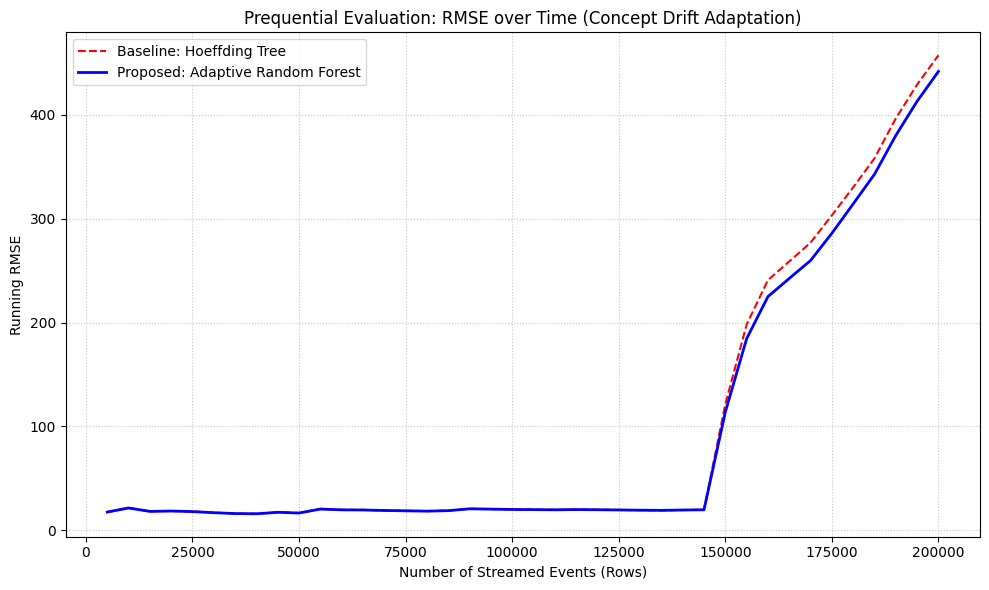

In [ ]:
from river import metrics
from river import tree
from river import forest 
from river import compose
from river import preprocessing
import matplotlib.pyplot as plt
import time
import gc

print("--- 1. Initializing the Comparative Study ---")
features = ['square_feet', 'air_temperature', 'HDD', 'CDD', 
            'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']
target = 'meter_reading'

# Model 1: Baseline (Single Hoeffding Tree)
model_ht = compose.Pipeline(
    preprocessing.StandardScaler(),
    tree.HoeffdingTreeRegressor()
)

# Model 2: Proposed (Adaptive Random Forest with 10 trees to balance speed and accuracy)
model_arf = compose.Pipeline(
    preprocessing.StandardScaler(),
    forest.ARFRegressor(n_models=10, seed=42)  # Cập nhật: Sử dụng ARFRegressor
)

# Metrics tracking
metric_ht_rmse = metrics.RMSE()
metric_arf_rmse = metrics.RMSE()

# Lists to store data for the Learning Curve plot
steps = []
ht_errors = []
arf_errors = []

print("--- 2. Starting Parallel Prequential Evaluation ---")
# Re-initialize the stream to start from the beginning of the CSV
data_stream = stream_data(processed_file_path)
processed_count = 0
start_time = time.time()

for event in data_stream:
    try:
        x = {feat: float(event[feat]) for feat in features if event[feat] != ''}
        y = float(event[target])
        
        # --- Evaluate and Learn Model 1 (Baseline) ---
        y_pred_ht = model_ht.predict_one(x)
        metric_ht_rmse.update(y, y_pred_ht)
        model_ht.learn_one(x, y)
        
        # --- Evaluate and Learn Model 2 (Proposed ARF) ---
        y_pred_arf = model_arf.predict_one(x)
        metric_arf_rmse.update(y, y_pred_arf)
        model_arf.learn_one(x, y)
        
        processed_count += 1
        
        # Record metrics every 5,000 steps for plotting
        if processed_count % 5000 == 0:
            steps.append(processed_count)
            ht_errors.append(metric_ht_rmse.get())
            arf_errors.append(metric_arf_rmse.get())
            
        # Print progress every 50,000 steps
        if processed_count % 50000 == 0:
            print(f"Processed: {processed_count} rows | HT RMSE: {metric_ht_rmse.get():.4f} | ARF RMSE: {metric_arf_rmse.get():.4f}")
            
        # Stop at 200,000 for this comparative study
        if processed_count >= 200000:
            break
            
    except Exception as e:
        continue

elapsed = time.time() - start_time
print(f"\nPhase 4 Complete. Total time: {elapsed:.2f} seconds.")

print("\n--- 3. Final System RAM Check ---")
print_memory_usage()
gc.collect()

print("\n--- 4. Generating Learning Curve Plot ---")
plt.figure(figsize=(10, 6))
plt.plot(steps, ht_errors, label='Baseline: Hoeffding Tree', color='red', linestyle='--')
plt.plot(steps, arf_errors, label='Proposed: Adaptive Random Forest', color='blue', linewidth=2)
plt.title('Prequential Evaluation: RMSE over Time (Concept Drift Adaptation)')
plt.xlabel('Number of Streamed Events (Rows)')
plt.ylabel('Running RMSE')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()